# Neural Decoding of Movement Direction from BCI2000 SEEG

This notebook asks whether **movement direction can be predicted from neural data alone**.

It builds directly on the prior finding that **IL11, left posterior insula, showed direction-related HFB activity**.

## Core goals

1. Decode **target/cursor direction** from intracranial neural activity.
2. Decode **actual joystick movement direction** from intracranial neural activity.
3. Compare:
   - IL11 alone
   - the entire IL electrode shaft
   - all intracranial HFB features
   - all intracranial multi-band features
   - pre-movement versus movement-period neural activity
4. Evaluate performance using:
   - repeated stratified cross-validation
   - leave-one-task-block-out cross-validation
   - permutation testing
   - confusion matrices
5. Inspect which neural contacts contribute most strongly.
6. Check whether apparent decoding could instead be driven by:
   - raw-amplitude artifacts
   - 60/120/180 Hz line noise
   - global HFB fluctuations
   - task-block / recording-time confounds

## Critical leakage rule

**TargetX, TargetY, TargetAngle, joystick states, task states, and eye-tracker states are used only to create labels and trial metadata. They are never included as classifier input features.**

The classifier input is derived only from the continuous intracranial neural signal.


In [1]:
from pathlib import Path
import re
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from scipy.signal import welch
from scipy.stats import (
    spearmanr,
    f_oneway,
)

try:
    from sklearn.base import clone
    from sklearn.pipeline import Pipeline
    from sklearn.preprocessing import StandardScaler
    from sklearn.feature_selection import SelectKBest, f_classif
    from sklearn.linear_model import LogisticRegression
    from sklearn.dummy import DummyClassifier
    from sklearn.model_selection import (
        StratifiedKFold,
        RepeatedStratifiedKFold,
        GroupKFold,
        cross_validate,
        cross_val_predict,
        permutation_test_score,
    )
    from sklearn.metrics import (
        accuracy_score,
        balanced_accuracy_score,
        confusion_matrix,
        ConfusionMatrixDisplay,
        classification_report,
    )
except ImportError as exc:
    raise ImportError(
        "This notebook requires scikit-learn. "
        "Install it in your environment with:\n"
        "pip install scikit-learn joblib"
    ) from exc

from BCI2000Tools.FileReader import bcistream

pd.set_option("display.max_columns", 160)
pd.set_option("display.width", 180)
pd.set_option("display.max_rows", 120)

RANDOM_STATE = 42
RNG = np.random.default_rng(RANDOM_STATE)


## 1. Select the BCI2000 recording


In [2]:
DAT_PATH = Path(
    r"C:\Users\gabri\Desktop\joystick_test_env\python_da\patient_data\ECOGS001R02.dat"
)

if not DAT_PATH.is_file():
    raise FileNotFoundError(
        f"File not found: {DAT_PATH}\n"
        "Edit DAT_PATH so it points to the correct BCI2000 .dat file."
    )

print(f"Using: {DAT_PATH.resolve()}")


Using: C:\Users\gabri\Desktop\joystick_test_env\python_da\patient_data\ECOGS001R02.dat


## 2. Load neural signal and only the states needed to build trial labels


In [3]:
stream = bcistream(str(DAT_PATH))

requested_states = [
    "TaskCondition",
    "TaskBlockType",
    "TaskBlock",
    "TaskTrial",
    "TargetAngle",
    "TargetX",
    "TargetY",
    "MovementStarted",
    "TargetHit",
    "Introduction",
    "PracticeTrial",
    "ReactionTimeMs",
    "MovementTimeMs",
    "TotalTimeMs",
    "JoystickXpos",
    "JoystickYpos",
]

available_states = [
    name
    for name in requested_states
    if name in stream.statedefs
]

signal_raw, decoded_states = stream.decode(
    nsamp="all",
    states=available_states,
)

signal_raw = np.asarray(signal_raw)

n_channels = int(stream.nchan)
n_samples = int(stream.samples())
fs = float(stream.samplingfreq_hz)

if signal_raw.shape == (n_channels, n_samples):
    signal = signal_raw.T
elif signal_raw.shape == (n_samples, n_channels):
    signal = signal_raw
else:
    raise ValueError(
        f"Unexpected signal shape: {signal_raw.shape}"
    )

states = {
    name: np.asarray(decoded_states[name]).ravel()
    for name in available_states
}

print(f"Signal shape:   {signal.shape}")
print(f"Sampling rate: {fs:g} Hz")
print(f"Duration:      {n_samples / fs / 60:.2f} minutes")
print(f"States loaded: {len(states)}")


Signal shape:   (1255100, 256)
Sampling rate: 2000 Hz
Duration:      10.46 minutes
States loaded: 14


## 3. Identify intracranial contacts

Scalp EEG, EKG, reference, and empty channels are excluded from decoding.


In [4]:
channel_names = [
    str(name).strip()
    for name in stream.params["ChannelNames"]
]

implant_targets = {
    "AL": "L temporal pole",
    "BL": "L amygdala",
    "CL": "L hippocampal head",
    "DL": "L hippocampal tail",
    "EL": "L fusiform",
    "FL": "L orbitofrontal",
    "GL": "L opercular",
    "HL": "L anterior insula ventral",
    "IL": "L posterior insula",
    "AR": "R temporal pole",
    "BR": "R amygdala",
    "CR": "R hippocampal head",
    "DR": "R hippocampal tail",
    "ER": "R fusiform",
    "FR": "R orbitofrontal",
    "GR": "R opercular",
    "HR": "R anterior insula ventral",
    "IR": "R posterior insula",
}

rows = []

for signal_index, name in enumerate(channel_names):
    match = re.fullmatch(
        r"([A-Z]{2})(\d+)",
        name,
    )

    if match and match.group(1) in implant_targets:
        electrode = match.group(1)

        rows.append({
            "signal_index": signal_index,
            "BCI2000_channel": signal_index + 1,
            "channel_name": name,
            "electrode": electrode,
            "contact": int(match.group(2)),
            "implant_target": implant_targets[electrode],
        })

intracranial_channels = pd.DataFrame(rows)

intracranial_indices = intracranial_channels[
    "signal_index"
].to_numpy()

intracranial_names = intracranial_channels[
    "channel_name"
].to_numpy()

print(f"Intracranial contacts: {len(intracranial_channels)}")


Intracranial contacts: 202


## 4. Build one row per completed trial

The notebook derives two different direction labels:

### Target direction
Direction from the center of the target circle to the displayed target.

### Joystick direction
Direction of the participant's actual physical joystick movement from `MovementStarted` to `TargetHit`.

This distinction matters because Controlled trials invert the visuomotor mapping. Neural activity may encode the visual target/cursor direction, the physical hand movement direction, or both.


In [5]:
def rising_edges(values):
    values = np.asarray(values)
    active = values > 0

    edges = np.flatnonzero(
        active[1:] & ~active[:-1]
    ) + 1

    if active.size and active[0]:
        edges = np.r_[0, edges]

    return edges.astype(int)


for needed in [
    "TaskBlock",
    "TaskTrial",
    "MovementStarted",
    "TargetHit",
    "TargetX",
    "TargetY",
    "JoystickXpos",
    "JoystickYpos",
]:
    if needed not in states:
        raise KeyError(
            f"Required state missing: {needed}"
        )

movement_onsets = rising_edges(
    states["MovementStarted"]
)

hit_samples = rising_edges(
    states["TargetHit"]
)

experimental_mask = np.ones(
    n_samples,
    dtype=bool,
)

if "Introduction" in states:
    experimental_mask &= (
        states["Introduction"] == 0
    )

experimental_mask &= states["TaskBlock"] > 0
experimental_mask &= states["TaskTrial"] > 0

if "PracticeTrial" in states:
    experimental_mask &= (
        states["PracticeTrial"] == 0
    )

movement_onsets = movement_onsets[
    experimental_mask[movement_onsets]
]

hit_samples = hit_samples[
    experimental_mask[hit_samples]
]

trial_rows = []

for hit in hit_samples:
    block = int(
        states["TaskBlock"][hit]
    )

    trial = int(
        states["TaskTrial"][hit]
    )

    candidates = movement_onsets[
        (movement_onsets <= hit)
        & (
            states["TaskBlock"][movement_onsets]
            == block
        )
        & (
            states["TaskTrial"][movement_onsets]
            == trial
        )
    ]

    if candidates.size == 0:
        continue

    onset = int(
        candidates[-1]
    )

    # Use several samples near the beginning/end to make
    # joystick direction more robust than a single sample.
    early_stop = min(
        onset + max(5, int(round(0.05 * fs))),
        hit + 1,
    )

    late_start = max(
        onset,
        hit - max(5, int(round(0.05 * fs))),
    )

    joystick_start_x = np.nanmedian(
        states["JoystickXpos"][
            onset:early_stop
        ].astype(float)
    )

    joystick_start_y = np.nanmedian(
        states["JoystickYpos"][
            onset:early_stop
        ].astype(float)
    )

    joystick_end_x = np.nanmedian(
        states["JoystickXpos"][
            late_start:hit + 1
        ].astype(float)
    )

    joystick_end_y = np.nanmedian(
        states["JoystickYpos"][
            late_start:hit + 1
        ].astype(float)
    )

    row = {
        "block": block,
        "trial": trial,
        "movement_onset_sample": onset,
        "target_hit_sample": int(hit),
        "movement_onset_s": onset / fs,
        "target_hit_s": hit / fs,
        "TargetX": float(states["TargetX"][onset]),
        "TargetY": float(states["TargetY"][onset]),
        "joystick_start_x": joystick_start_x,
        "joystick_start_y": joystick_start_y,
        "joystick_end_x": joystick_end_x,
        "joystick_end_y": joystick_end_y,
    }

    for name in [
        "TaskCondition",
        "TaskBlockType",
        "TargetAngle",
        "ReactionTimeMs",
        "MovementTimeMs",
        "TotalTimeMs",
    ]:
        if name in states:
            row[name] = states[name][hit]

    trial_rows.append(row)

trials = pd.DataFrame(
    trial_rows
)

if trials.empty:
    raise RuntimeError(
        "No completed trials were matched."
    )

if "TaskCondition" in trials.columns:
    trials["condition"] = (
        trials["TaskCondition"]
        .map({
            0: "Automatic",
            1: "Controlled",
        })
    )

if "TaskBlockType" in trials.columns:
    trials["context"] = np.where(
        trials["TaskBlockType"] == 2,
        "Pseudorandom",
        "Ordered",
    )

trials["analysis_trial_index"] = np.arange(
    len(trials)
)

print(f"Matched completed trials: {len(trials)}")


Matched completed trials: 80


## 5. Fit the target circle and derive continuous target direction


In [6]:
def fit_circle_center(
    x,
    y,
):
    x = np.asarray(
        x,
        dtype=float,
    )

    y = np.asarray(
        y,
        dtype=float,
    )

    valid = (
        np.isfinite(x)
        & np.isfinite(y)
    )

    x = x[valid]
    y = y[valid]

    A = np.column_stack([
        x,
        y,
        np.ones(len(x)),
    ])

    b = -(
        x ** 2
        + y ** 2
    )

    D, E, F = np.linalg.lstsq(
        A,
        b,
        rcond=None,
    )[0]

    center_x = -D / 2
    center_y = -E / 2

    radius = np.sqrt(
        max(
            0,
            center_x ** 2
            + center_y ** 2
            - F,
        )
    )

    return (
        center_x,
        center_y,
        radius,
    )


target_center_x, target_center_y, target_radius = (
    fit_circle_center(
        trials["TargetX"].to_numpy(),
        trials["TargetY"].to_numpy(),
    )
)

target_dx = (
    trials["TargetX"].to_numpy()
    - target_center_x
)

target_dy = (
    trials["TargetY"].to_numpy()
    - target_center_y
)

trials["target_direction_deg"] = (
    np.degrees(
        np.arctan2(
            -target_dy,
            target_dx,
        )
    )
    % 360
)

print(
    f"Target center: X={target_center_x:.2f}, "
    f"Y={target_center_y:.2f}"
)

print(
    f"Target radius: {target_radius:.2f}"
)


Target center: X=510.05, Y=518.90
Target radius: 293.65


## 6. Derive actual joystick movement direction


In [7]:
joystick_dx = (
    trials["joystick_end_x"].to_numpy()
    - trials["joystick_start_x"].to_numpy()
)

joystick_dy = (
    trials["joystick_end_y"].to_numpy()
    - trials["joystick_start_y"].to_numpy()
)

trials["joystick_displacement"] = np.hypot(
    joystick_dx,
    joystick_dy,
)

trials["joystick_direction_deg"] = (
    np.degrees(
        np.arctan2(
            -joystick_dy,
            joystick_dx,
        )
    )
    % 360
)

display(
    trials[
        [
            "trial",
            "condition",
            "TargetX",
            "TargetY",
            "target_direction_deg",
            "joystick_direction_deg",
            "joystick_displacement",
        ]
    ].head(20)
)


,trial,condition,TargetX,TargetY,target_direction_deg,joystick_direction_deg,joystick_displacement
0,1,Automatic,359.0,776.0,239.564952,189.731215,1331.153259
1,2,Automatic,336.0,273.0,125.290608,80.323729,7044.216919
2,3,Automatic,293.0,674.0,215.548396,188.096428,4331.171204
3,4,Automatic,367.0,784.0,241.648195,214.878371,2808.496395
4,5,Automatic,402.0,211.0,109.336899,109.332377,10922.898196
5,6,Automatic,745.0,631.0,334.493952,275.261994,5604.619256
6,7,Automatic,359.0,777.0,239.662006,221.333679,6712.159787
7,8,Automatic,303.0,327.0,137.174059,75.593315,3601.244229
8,9,Automatic,739.0,372.0,32.685775,69.119872,993.227064
9,10,Automatic,640.0,224.0,66.219035,53.558914,6760.989351


## 7. Sanity check: target direction versus physical joystick direction

For Automatic trials, the two directions should be relatively similar.

For Controlled/inverted trials, they may differ by approximately 180 degrees.

If this pattern is not present, inspect the joystick-angle derivation before interpreting the classifier.


,count,mean,median,std
condition,,,,
Automatic,40,-12.755870,-10.524010,18.135294
Controlled,40,-122.120989,-173.982853,123.825933


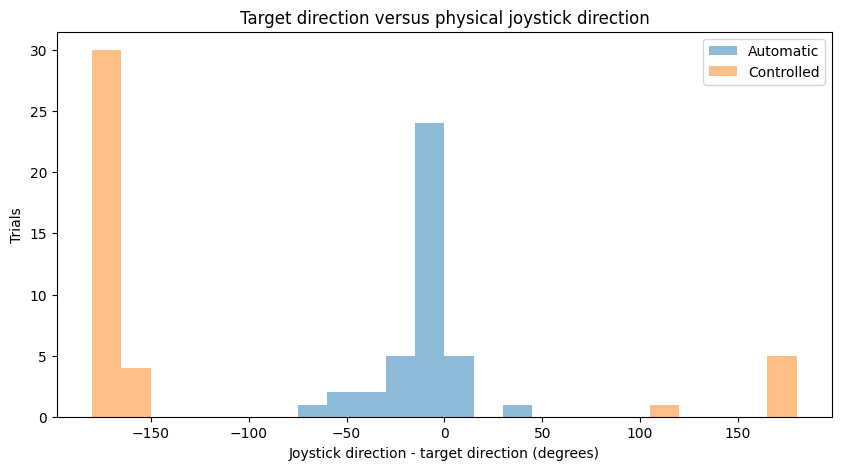

In [8]:
def circular_difference_deg(
    a,
    b,
):
    return (
        (
            a - b + 180
        )
        % 360
        - 180
    )


trials["joystick_minus_target_deg"] = (
    circular_difference_deg(
        trials[
            "joystick_direction_deg"
        ].to_numpy(),
        trials[
            "target_direction_deg"
        ].to_numpy(),
    )
)

if "condition" in trials.columns:
    display(
        trials.groupby(
            "condition"
        )[
            "joystick_minus_target_deg"
        ].agg([
            "count",
            "mean",
            "median",
            "std",
        ])
    )

fig, ax = plt.subplots(
    figsize=(10, 5)
)

for condition_name in (
    trials["condition"].dropna().unique()
    if "condition" in trials.columns
    else ["All"]
):
    if "condition" in trials.columns:
        values = trials.loc[
            trials["condition"] == condition_name,
            "joystick_minus_target_deg",
        ]
    else:
        values = trials[
            "joystick_minus_target_deg"
        ]

    ax.hist(
        values,
        bins=np.arange(
            -180,
            181,
            15,
        ),
        alpha=0.5,
        label=condition_name,
    )

ax.set_xlabel(
    "Joystick direction - target direction (degrees)"
)

ax.set_ylabel(
    "Trials"
)

ax.set_title(
    "Target direction versus physical joystick direction"
)

ax.legend()
plt.show()


# Part A: Convert continuous directions into classification labels

By default the notebook uses **4 direction classes** because there are only 80 completed trials.

For the angle convention used here:

- 0 degrees = Right
- 90 degrees = Up
- 180 degrees = Left
- 270 degrees = Down

Change `N_DIRECTION_CLASSES` to 8 if you want a harder eight-direction decoder.

With only 80 trials, 4-way decoding is the more statistically stable first analysis.


In [9]:
N_DIRECTION_CLASSES = 4

if N_DIRECTION_CLASSES not in {
    4,
    8,
}:
    raise ValueError(
        "N_DIRECTION_CLASSES must be 4 or 8."
    )


def angle_to_class(
    angles_deg,
    n_classes,
):
    angles_deg = np.asarray(
        angles_deg,
        dtype=float,
    )

    step = 360.0 / n_classes

    indices = (
        np.floor(
            (
                angles_deg
                + step / 2
            )
            % 360
            / step
        )
        .astype(int)
    )

    if n_classes == 4:
        names = np.array([
            "Right",
            "Up",
            "Left",
            "Down",
        ])
    else:
        names = np.array([
            "Right",
            "Up-Right",
            "Up",
            "Up-Left",
            "Left",
            "Down-Left",
            "Down",
            "Down-Right",
        ])

    return (
        indices,
        names[indices],
        names,
    )


(
    trials["target_class_id"],
    trials["target_class"],
    TARGET_CLASS_NAMES,
) = angle_to_class(
    trials[
        "target_direction_deg"
    ].to_numpy(),
    N_DIRECTION_CLASSES,
)

(
    trials["joystick_class_id"],
    trials["joystick_class"],
    JOYSTICK_CLASS_NAMES,
) = angle_to_class(
    trials[
        "joystick_direction_deg"
    ].to_numpy(),
    N_DIRECTION_CLASSES,
)

print("Target direction class counts:")
display(
    trials[
        "target_class"
    ].value_counts()
)

print("\nJoystick direction class counts:")
display(
    trials[
        "joystick_class"
    ].value_counts()
)


Target direction class counts:


target_class
Down     28
Up       22
Left     17
Right    13
Name: count, dtype: int64


Joystick direction class counts:


joystick_class
Up       32
Left     24
Down     16
Right     8
Name: count, dtype: int64

## A1. Plot trial directions and their classes


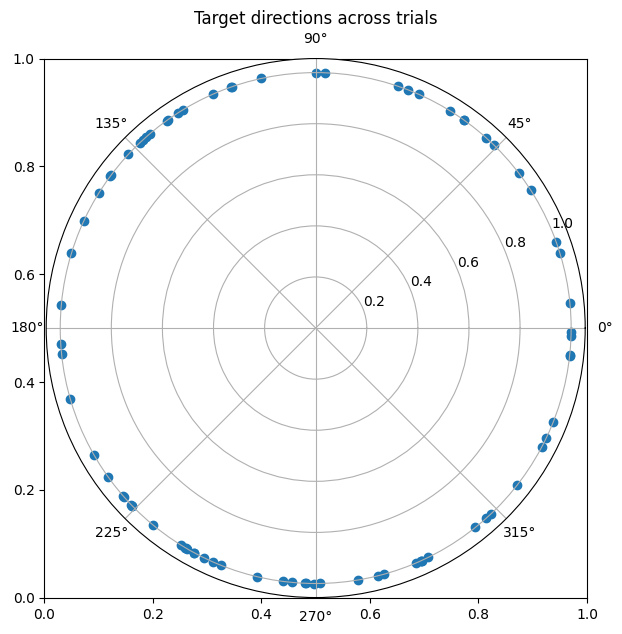

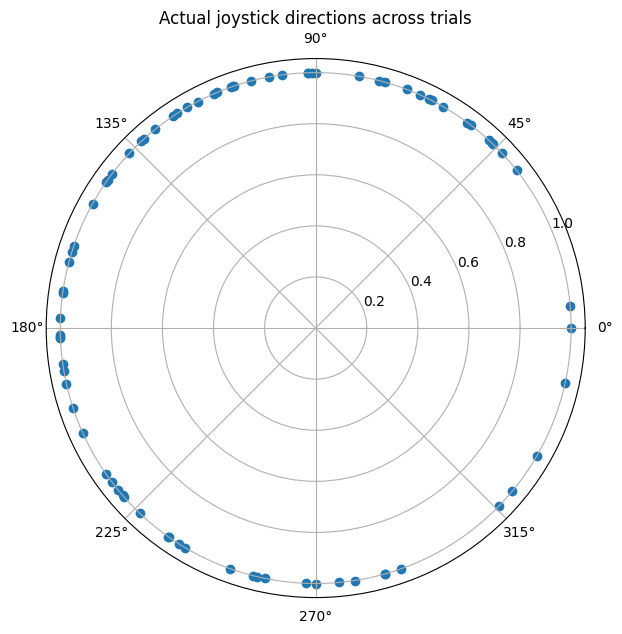

In [10]:
fig, ax = plt.subplots(
    figsize=(7, 7)
)

theta = np.deg2rad(
    trials[
        "target_direction_deg"
    ].to_numpy()
)

radius = np.ones(
    len(theta)
)

ax = plt.subplot(
    111,
    projection="polar",
)

ax.scatter(
    theta,
    radius,
)

ax.set_title(
    "Target directions across trials"
)

plt.show()

fig = plt.figure(
    figsize=(7, 7)
)

ax = fig.add_subplot(
    111,
    projection="polar",
)

theta = np.deg2rad(
    trials[
        "joystick_direction_deg"
    ].to_numpy()
)

ax.scatter(
    theta,
    np.ones(
        len(theta)
    ),
)

ax.set_title(
    "Actual joystick directions across trials"
)

plt.show()


# Part B: Extract neural spectral features

Features are computed from the intracranial neural signal only.

Two periods are analyzed separately:

### Pre-movement
Baseline: -1.00 to -0.50 s  
Feature window: -0.50 to 0.00 s

This asks whether neural data can predict direction **before physical movement begins**.

### Movement
Baseline: -0.75 to -0.25 s  
Feature window: 0.00 to +0.50 s

This asks whether neural data predicts direction during the initial movement period.

Frequency bands:

- theta: 4-8 Hz
- alpha: 8-12 Hz
- beta: 13-30 Hz
- low gamma: 30-55 Hz
- HFB: 70-150 Hz

60/120/180 Hz line-noise neighborhoods are excluded when they fall inside a band.


In [11]:
WINDOWS = {
    "premovement": {
        "baseline": (-1.00, -0.50),
        "active": (-0.50, 0.00),
    },
    "movement": {
        "baseline": (-0.75, -0.25),
        "active": (0.00, 0.50),
    },
}

BANDS = {
    "theta": (4.0, 8.0),
    "alpha": (8.0, 12.0),
    "beta": (13.0, 30.0),
    "low_gamma": (30.0, 55.0),
    "hfb": (70.0, 150.0),
}

LINE_FREQS = (
    60.0,
    120.0,
    180.0,
)

LINE_HALF_WIDTH_HZ = 2.0


def spectral_density(
    segment,
    fs,
):
    nperseg = min(
        segment.shape[0],
        max(
            64,
            int(
                round(
                    fs * 0.5
                )
            ),
        ),
    )

    f, pxx = welch(
        segment,
        fs=fs,
        axis=0,
        nperseg=nperseg,
        noverlap=nperseg // 2,
        detrend="constant",
        scaling="density",
    )

    return f, pxx


def integrate_band(
    f,
    pxx,
    low,
    high,
):
    mask = (
        (f >= low)
        & (f <= high)
    )

    for frequency in LINE_FREQS:
        mask &= (
            np.abs(
                f - frequency
            )
            > LINE_HALF_WIDTH_HZ
        )

    if mask.sum() < 2:
        raise ValueError(
            f"Not enough frequency bins for {low}-{high} Hz."
        )

    return np.trapezoid(
        pxx[mask],
        f[mask],
        axis=0,
    )


def frequency_bin_power(
    f,
    pxx,
    target_frequency,
):
    index = np.argmin(
        np.abs(
            f - target_frequency
        )
    )

    return pxx[
        index
    ]


## B1. Extract trial × channel matrices for each window and band

Every value is a dB change relative to that trial's own baseline:

`10 * log10(active power / baseline power)`


In [12]:
feature_matrices = {
    window_name: {
        band_name: []
        for band_name in BANDS
    }
    for window_name in WINDOWS
}

artifact_metrics = {
    "movement_ptp_median": [],
    "movement_rms_median": [],
    "movement_120_abs_median": [],
    "movement_ptp_p99": [],
}

kept_trial_indices = []

for trial_index, row in trials.iterrows():
    onset = int(
        row[
            "movement_onset_sample"
        ]
    )

    trial_features = {}
    valid_trial = True

    for window_name, config in WINDOWS.items():
        b0 = onset + int(
            round(
                config["baseline"][0]
                * fs
            )
        )

        b1 = onset + int(
            round(
                config["baseline"][1]
                * fs
            )
        )

        a0 = onset + int(
            round(
                config["active"][0]
                * fs
            )
        )

        a1 = onset + int(
            round(
                config["active"][1]
                * fs
            )
        )

        if (
            b0 < 0
            or b1 > n_samples
            or a0 < 0
            or a1 > n_samples
        ):
            valid_trial = False
            break

        baseline = signal[
            b0:b1,
            intracranial_indices,
        ].astype(
            np.float64
        )

        active = signal[
            a0:a1,
            intracranial_indices,
        ].astype(
            np.float64
        )

        f_b, p_b = spectral_density(
            baseline,
            fs,
        )

        f_a, p_a = spectral_density(
            active,
            fs,
        )

        if not np.allclose(
            f_b,
            f_a,
        ):
            raise RuntimeError(
                "Baseline and active frequency bins differ."
            )

        trial_features[
            window_name
        ] = {}

        for band_name, (
            low,
            high,
        ) in BANDS.items():
            baseline_power = integrate_band(
                f_b,
                p_b,
                low,
                high,
            )

            active_power = integrate_band(
                f_a,
                p_a,
                low,
                high,
            )

            response_db = (
                10
                * np.log10(
                    (
                        active_power
                        + np.finfo(
                            float
                        ).tiny
                    )
                    /
                    (
                        baseline_power
                        + np.finfo(
                            float
                        ).tiny
                    )
                )
            )

            trial_features[
                window_name
            ][
                band_name
            ] = response_db

    if not valid_trial:
        continue

    for window_name in WINDOWS:
        for band_name in BANDS:
            feature_matrices[
                window_name
            ][
                band_name
            ].append(
                trial_features[
                    window_name
                ][
                    band_name
                ]
            )

    # Artifact metrics use the movement active window.
    movement_config = WINDOWS[
        "movement"
    ]

    m0 = onset + int(
        round(
            movement_config[
                "active"
            ][0]
            * fs
        )
    )

    m1 = onset + int(
        round(
            movement_config[
                "active"
            ][1]
            * fs
        )
    )

    b0 = onset + int(
        round(
            movement_config[
                "baseline"
            ][0]
            * fs
        )
    )

    b1 = onset + int(
        round(
            movement_config[
                "baseline"
            ][1]
            * fs
        )
    )

    movement_signal = signal[
        m0:m1,
        intracranial_indices,
    ].astype(
        np.float64
    )

    baseline_signal = signal[
        b0:b1,
        intracranial_indices,
    ].astype(
        np.float64
    )

    movement_ptp = (
        np.nanmax(
            movement_signal,
            axis=0,
        )
        - np.nanmin(
            movement_signal,
            axis=0,
        )
    )

    movement_rms = np.sqrt(
        np.nanmean(
            movement_signal ** 2,
            axis=0,
        )
    )

    f_b_line, p_b_line = (
        spectral_density(
            baseline_signal,
            fs,
        )
    )

    f_m_line, p_m_line = (
        spectral_density(
            movement_signal,
            fs,
        )
    )

    base_120 = frequency_bin_power(
        f_b_line,
        p_b_line,
        120.0,
    )

    move_120 = frequency_bin_power(
        f_m_line,
        p_m_line,
        120.0,
    )

    line120_change = (
        10
        * np.log10(
            (
                move_120
                + np.finfo(float).tiny
            )
            /
            (
                base_120
                + np.finfo(float).tiny
            )
        )
    )

    artifact_metrics[
        "movement_ptp_median"
    ].append(
        np.nanmedian(
            movement_ptp
        )
    )

    artifact_metrics[
        "movement_rms_median"
    ].append(
        np.nanmedian(
            movement_rms
        )
    )

    artifact_metrics[
        "movement_120_abs_median"
    ].append(
        np.nanmedian(
            np.abs(
                line120_change
            )
        )
    )

    artifact_metrics[
        "movement_ptp_p99"
    ].append(
        np.nanpercentile(
            movement_ptp,
            99,
        )
    )

    kept_trial_indices.append(
        trial_index
    )

for window_name in feature_matrices:
    for band_name in feature_matrices[
        window_name
    ]:
        feature_matrices[
            window_name
        ][
            band_name
        ] = np.vstack(
            feature_matrices[
                window_name
            ][
                band_name
            ]
        )

for metric_name in artifact_metrics:
    artifact_metrics[
        metric_name
    ] = np.asarray(
        artifact_metrics[
            metric_name
        ]
    )

neural_trials = (
    trials.loc[
        kept_trial_indices
    ]
    .reset_index(
        drop=True
    )
)

print(
    f"Trials with complete neural windows: "
    f"{len(neural_trials)}"
)

print(
    "Movement HFB shape:",
    feature_matrices[
        "movement"
    ][
        "hfb"
    ].shape,
)


Trials with complete neural windows: 80
Movement HFB shape: (80, 202)


# Part C: Trial-level artifact exclusion

A classifier can exploit an artifact if the artifact happens to occur more often for one direction.

The notebook therefore flags extreme trials based on recording-wide neural metrics:

- median raw peak-to-peak amplitude
- 99th percentile peak-to-peak amplitude
- median raw RMS
- median absolute 120 Hz change

A trial is flagged when a metric is more than 6 robust MAD units above the median.


In [13]:
def robust_high_outliers(
    values,
    threshold=6.0,
):
    values = np.asarray(
        values,
        dtype=float,
    )

    median = np.nanmedian(
        values
    )

    mad = np.nanmedian(
        np.abs(
            values - median
        )
    )

    if (
        not np.isfinite(mad)
        or mad == 0
    ):
        return np.zeros(
            len(values),
            dtype=bool,
        )

    robust_z = (
        0.6745
        * (
            values - median
        )
        / mad
    )

    return (
        robust_z
        > threshold
    )


artifact_flags = np.zeros(
    len(neural_trials),
    dtype=bool,
)

artifact_table = pd.DataFrame(
    artifact_metrics
)

for metric_name in artifact_table.columns:
    flag = robust_high_outliers(
        artifact_table[
            metric_name
        ].to_numpy()
    )

    artifact_table[
        f"{metric_name}_flag"
    ] = flag

    artifact_flags |= flag

artifact_table[
    "artifact_flag"
] = artifact_flags

EXCLUDE_ARTIFACT_TRIALS = True

if EXCLUDE_ARTIFACT_TRIALS:
    analysis_mask = (
        ~artifact_flags
    )
else:
    analysis_mask = np.ones(
        len(neural_trials),
        dtype=bool,
    )

print(
    f"Artifact-flagged trials: "
    f"{artifact_flags.sum()} / "
    f"{len(artifact_flags)}"
)

print(
    f"Trials entering classifier: "
    f"{analysis_mask.sum()}"
)

display(
    artifact_table.loc[
        artifact_table[
            "artifact_flag"
        ]
    ]
)


Artifact-flagged trials: 0 / 80
Trials entering classifier: 80


,movement_ptp_median,movement_rms_median,movement_120_abs_median,movement_ptp_p99,movement_ptp_median_flag,movement_rms_median_flag,movement_120_abs_median_flag,movement_ptp_p99_flag,artifact_flag


## C1. Make sure artifact flags are not direction-specific

If one direction has substantially more flagged trials than another, classification results should be interpreted cautiously.


In [14]:
artifact_by_target = pd.crosstab(
    neural_trials[
        "target_class"
    ],
    artifact_flags,
)

artifact_by_joystick = pd.crosstab(
    neural_trials[
        "joystick_class"
    ],
    artifact_flags,
)

print("Artifact flags by target class:")
display(
    artifact_by_target
)

print("\nArtifact flags by joystick class:")
display(
    artifact_by_joystick
)


Artifact flags by target class:


col_0,False
target_class,
Down,28
Left,17
Right,13
Up,22



Artifact flags by joystick class:


col_0,False
joystick_class,
Down,16
Left,24
Right,8
Up,32


# Part D: Build decoding datasets

Global-HFB correction subtracts the trial-wise median across all intracranial contacts from each channel.

That specifically tests whether decoding depends on spatially local differences rather than a recording-wide HFB fluctuation.


In [15]:
def global_correct(
    matrix,
):
    matrix = np.asarray(
        matrix,
        dtype=float,
    )

    return (
        matrix
        - np.nanmedian(
            matrix,
            axis=1,
            keepdims=True,
        )
    )


il_mask = (
    intracranial_channels[
        "electrode"
    ].to_numpy()
    == "IL"
)

il11_mask = (
    intracranial_channels[
        "channel_name"
    ].to_numpy()
    == "IL11"
)

if il11_mask.sum() != 1:
    raise RuntimeError(
        "Could not uniquely identify IL11."
    )


def concatenate_multiband(
    window_name,
    global_correct_each_band=False,
):
    matrices = []
    names = []

    for band_name in BANDS:
        matrix = feature_matrices[
            window_name
        ][
            band_name
        ]

        if global_correct_each_band:
            matrix = global_correct(
                matrix
            )

        matrices.append(
            matrix
        )

        names.extend([
            f"{window_name}|{band_name}|{channel_name}"
            for channel_name in intracranial_names
        ])

    return (
        np.column_stack(
            matrices
        ),
        np.asarray(
            names
        ),
    )


movement_hfb = feature_matrices[
    "movement"
][
    "hfb"
]

premovement_hfb = feature_matrices[
    "premovement"
][
    "hfb"
]

movement_multiband, movement_multiband_names = (
    concatenate_multiband(
        "movement",
        global_correct_each_band=True,
    )
)

premovement_multiband, premovement_multiband_names = (
    concatenate_multiband(
        "premovement",
        global_correct_each_band=True,
    )
)

datasets = {
    "IL11 movement HFB": {
        "X": movement_hfb[
            :,
            il11_mask,
        ],
        "feature_names": np.asarray([
            "movement|hfb|IL11"
        ]),
        "select_k": "all",
    },
    "IL shaft movement HFB": {
        "X": movement_hfb[
            :,
            il_mask,
        ],
        "feature_names": np.asarray([
            f"movement|hfb|{name}"
            for name in intracranial_names[
                il_mask
            ]
        ]),
        "select_k": "all",
    },
    "All contacts movement HFB": {
        "X": movement_hfb,
        "feature_names": np.asarray([
            f"movement|hfb|{name}"
            for name in intracranial_names
        ]),
        "select_k": 30,
    },
    "All contacts movement HFB global-corrected": {
        "X": global_correct(
            movement_hfb
        ),
        "feature_names": np.asarray([
            f"movement|hfb|{name}"
            for name in intracranial_names
        ]),
        "select_k": 30,
    },
    "All contacts pre-movement HFB global-corrected": {
        "X": global_correct(
            premovement_hfb
        ),
        "feature_names": np.asarray([
            f"premovement|hfb|{name}"
            for name in intracranial_names
        ]),
        "select_k": 30,
    },
    "All contacts movement multi-band global-corrected": {
        "X": movement_multiband,
        "feature_names": movement_multiband_names,
        "select_k": 40,
    },
    "All contacts pre-movement multi-band global-corrected": {
        "X": premovement_multiband,
        "feature_names": premovement_multiband_names,
        "select_k": 40,
    },
}

dataset_summary = []

for dataset_name, info in datasets.items():
    dataset_summary.append({
        "dataset": dataset_name,
        "trials": info[
            "X"
        ].shape[0],
        "features": info[
            "X"
        ].shape[1],
        "selected_features_inside_CV": info[
            "select_k"
        ],
    })

display(
    pd.DataFrame(
        dataset_summary
    )
)


,dataset,trials,features,selected_features_inside_CV
0,IL11 movement HFB,80,1,all
1,IL shaft movement HFB,80,15,all
2,All contacts movement HFB,80,202,30
3,All contacts movement HFB global-corrected,80,202,30
4,All contacts pre-movement HFB global-corrected,80,202,30
5,All contacts movement multi-band global-corrected,80,1010,40
6,All contacts pre-movement multi-band global-co...,80,1010,40


# Part E: Leakage-safe classifier pipeline

The classifier is a regularized multinomial logistic regression.

For high-dimensional datasets, feature selection happens **inside each training fold** using `SelectKBest`.

This is important. Selecting features on the full dataset before cross-validation would leak information from the test trials into training and inflate accuracy.


In [16]:
def make_classifier(
    n_features,
    select_k,
):
    if select_k == "all":
        k = "all"
    else:
        k = min(
            int(select_k),
            int(n_features),
        )

    return Pipeline([
        (
            "select",
            SelectKBest(
                score_func=f_classif,
                k=k,
            ),
        ),
        (
            "scale",
            StandardScaler(),
        ),
        (
            "classifier",
            LogisticRegression(
                max_iter=5000,
                class_weight="balanced",
                solver="lbfgs",
                random_state=RANDOM_STATE,
            ),
        ),
    ])


dummy_classifier = DummyClassifier(
    strategy="prior",
    random_state=RANDOM_STATE,
)


# Part F: Repeated stratified cross-validation

This is the conventional decoding estimate.

The notebook uses 5-fold stratified CV repeated 10 times.

For a balanced 4-way problem, chance accuracy is approximately:

`1 / 4 = 25%`

Balanced accuracy is emphasized because it gives equal weight to each direction class.


In [17]:
N_SPLITS = 5
N_REPEATS = 10

random_cv = RepeatedStratifiedKFold(
    n_splits=N_SPLITS,
    n_repeats=N_REPEATS,
    random_state=RANDOM_STATE,
)


def evaluate_random_cv(
    X,
    y,
    select_k,
):
    X = X[
        analysis_mask
    ]

    y = y[
        analysis_mask
    ]

    model = make_classifier(
        X.shape[1],
        select_k,
    )

    scoring = {
        "accuracy": "accuracy",
        "balanced_accuracy": "balanced_accuracy",
    }

    result = cross_validate(
        model,
        X,
        y,
        cv=random_cv,
        scoring=scoring,
        n_jobs=-1,
    )

    dummy_result = cross_validate(
        dummy_classifier,
        X,
        y,
        cv=random_cv,
        scoring=scoring,
        n_jobs=-1,
    )

    return {
        "accuracy_mean": np.mean(
            result[
                "test_accuracy"
            ]
        ),
        "accuracy_sd": np.std(
            result[
                "test_accuracy"
            ]
        ),
        "balanced_accuracy_mean": np.mean(
            result[
                "test_balanced_accuracy"
            ]
        ),
        "balanced_accuracy_sd": np.std(
            result[
                "test_balanced_accuracy"
            ]
        ),
        "dummy_balanced_accuracy": np.mean(
            dummy_result[
                "test_balanced_accuracy"
            ]
        ),
    }


## F1. Compare neural feature sets for TARGET direction decoding


In [18]:
target_y = neural_trials[
    "target_class_id"
].to_numpy()

target_random_results = []

for dataset_name, info in datasets.items():
    result = evaluate_random_cv(
        info["X"],
        target_y,
        info["select_k"],
    )

    target_random_results.append({
        "label": "Target direction",
        "dataset": dataset_name,
        **result,
    })

target_random_results = pd.DataFrame(
    target_random_results
).sort_values(
    "balanced_accuracy_mean",
    ascending=False,
)

display(
    target_random_results
)


,label,dataset,accuracy_mean,accuracy_sd,balanced_accuracy_mean,balanced_accuracy_sd,dummy_balanced_accuracy
5,Target direction,All contacts movement multi-band global-corrected,0.34500,0.093742,0.315833,0.094810,0.25
0,Target direction,IL11 movement HFB,0.28125,0.079304,0.310667,0.086250,0.25
2,Target direction,All contacts movement HFB,0.29000,0.105149,0.291583,0.114814,0.25
4,Target direction,All contacts pre-movement HFB global-corrected,0.28125,0.098623,0.268333,0.102889,0.25
6,Target direction,All contacts pre-movement multi-band global-co...,0.28125,0.118090,0.261667,0.124094,0.25
1,Target direction,IL shaft movement HFB,0.26125,0.095762,0.255000,0.097436,0.25
3,Target direction,All contacts movement HFB global-corrected,0.25625,0.089486,0.250167,0.099850,0.25


## F2. Compare neural feature sets for ACTUAL JOYSTICK direction decoding


In [19]:
joystick_y = neural_trials[
    "joystick_class_id"
].to_numpy()

joystick_random_results = []

for dataset_name, info in datasets.items():
    result = evaluate_random_cv(
        info["X"],
        joystick_y,
        info["select_k"],
    )

    joystick_random_results.append({
        "label": "Joystick direction",
        "dataset": dataset_name,
        **result,
    })

joystick_random_results = pd.DataFrame(
    joystick_random_results
).sort_values(
    "balanced_accuracy_mean",
    ascending=False,
)

display(
    joystick_random_results
)


,label,dataset,accuracy_mean,accuracy_sd,balanced_accuracy_mean,balanced_accuracy_sd,dummy_balanced_accuracy
4,Joystick direction,All contacts pre-movement HFB global-corrected,0.34625,0.094547,0.305381,0.101688,0.25
3,Joystick direction,All contacts movement HFB global-corrected,0.31000,0.099184,0.247048,0.096651,0.25
6,Joystick direction,All contacts pre-movement multi-band global-co...,0.27875,0.121970,0.222750,0.106586,0.25
0,Joystick direction,IL11 movement HFB,0.19875,0.103599,0.216810,0.102790,0.25
1,Joystick direction,IL shaft movement HFB,0.25000,0.077055,0.212000,0.078574,0.25
5,Joystick direction,All contacts movement multi-band global-corrected,0.25750,0.094074,0.207167,0.091859,0.25
2,Joystick direction,All contacts movement HFB,0.26375,0.107740,0.204476,0.090117,0.25


## F3. Plot decoding performance


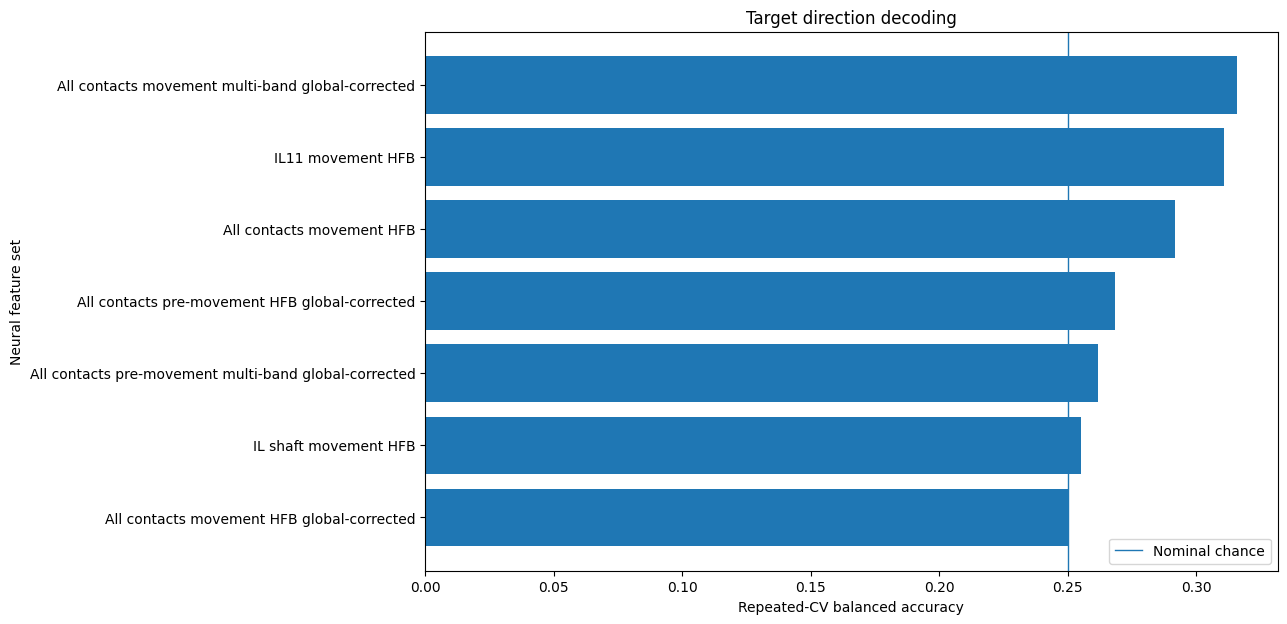

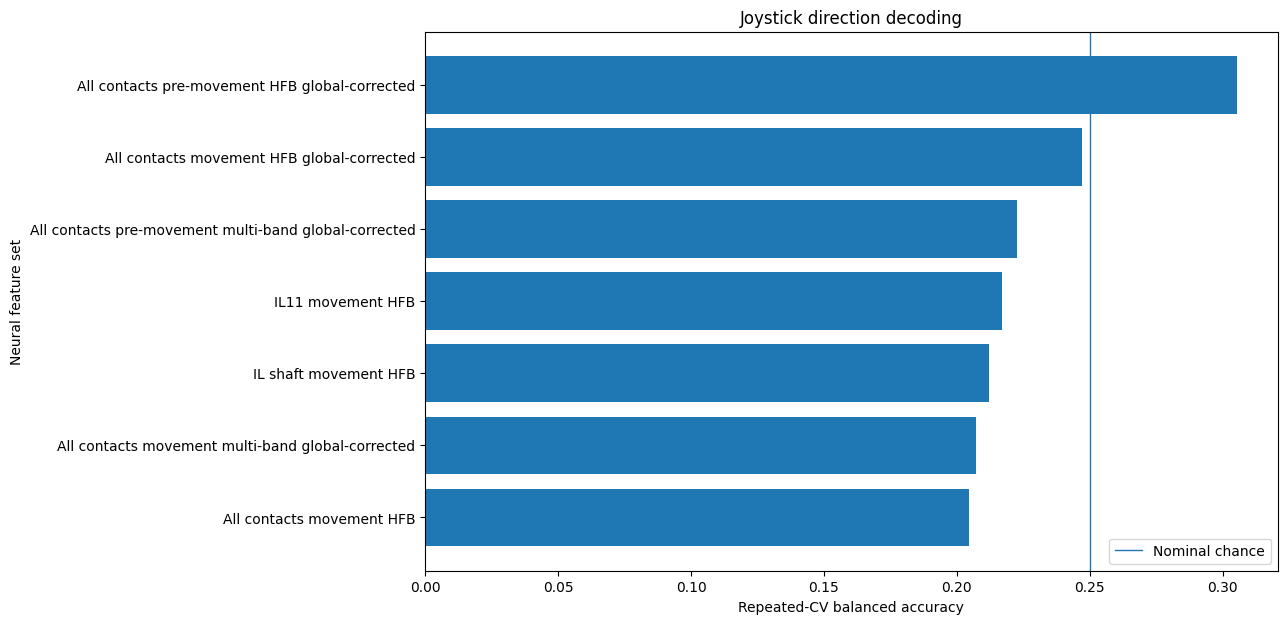

In [20]:
combined_random_results = pd.concat(
    [
        target_random_results,
        joystick_random_results,
    ],
    ignore_index=True,
)

for label_name in [
    "Target direction",
    "Joystick direction",
]:
    table = (
        combined_random_results.loc[
            combined_random_results[
                "label"
            ] == label_name
        ]
        .sort_values(
            "balanced_accuracy_mean"
        )
    )

    fig, ax = plt.subplots(
        figsize=(11, 7)
    )

    ax.barh(
        table[
            "dataset"
        ],
        table[
            "balanced_accuracy_mean"
        ],
    )

    ax.axvline(
        1.0
        / N_DIRECTION_CLASSES,
        linewidth=1,
        label="Nominal chance",
    )

    ax.set_xlabel(
        "Repeated-CV balanced accuracy"
    )

    ax.set_ylabel(
        "Neural feature set"
    )

    ax.set_title(
        f"{label_name} decoding"
    )

    ax.legend()
    plt.show()


# Part G: Leave-one-task-block-out evaluation

Randomly mixing trials across train and test folds can sometimes exploit slow recording drift.

A stricter test is to train on all but one `TaskBlock` and test on the held-out block.

This asks:

> Does the neural direction code generalize to a different section of the experiment?

If blocked-CV performance stays above chance, the decoding result is substantially more convincing.


In [21]:
groups = neural_trials[
    "block"
].to_numpy()

unique_groups = np.unique(
    groups[
        analysis_mask
    ]
)

print(
    f"Unique task blocks entering analysis: "
    f"{unique_groups}"
)

if len(unique_groups) < 2:
    raise RuntimeError(
        "Need at least two TaskBlock values for blocked CV."
    )

group_cv = GroupKFold(
    n_splits=len(
        unique_groups
    )
)


def evaluate_group_cv(
    X,
    y,
    select_k,
):
    X_use = X[
        analysis_mask
    ]

    y_use = y[
        analysis_mask
    ]

    groups_use = groups[
        analysis_mask
    ]

    model = make_classifier(
        X_use.shape[1],
        select_k,
    )

    result = cross_validate(
        model,
        X_use,
        y_use,
        groups=groups_use,
        cv=group_cv,
        scoring={
            "accuracy": "accuracy",
            "balanced_accuracy": "balanced_accuracy",
        },
        n_jobs=-1,
    )

    return {
        "blocked_accuracy_mean": np.mean(
            result[
                "test_accuracy"
            ]
        ),
        "blocked_accuracy_sd": np.std(
            result[
                "test_accuracy"
            ]
        ),
        "blocked_balanced_accuracy_mean": np.mean(
            result[
                "test_balanced_accuracy"
            ]
        ),
        "blocked_balanced_accuracy_sd": np.std(
            result[
                "test_balanced_accuracy"
            ]
        ),
    }


Unique task blocks entering analysis: [1 2 3]


## G1. Blocked decoding results


In [22]:
blocked_rows = []

for label_name, y in [
    (
        "Target direction",
        target_y,
    ),
    (
        "Joystick direction",
        joystick_y,
    ),
]:
    for dataset_name, info in datasets.items():
        try:
            result = evaluate_group_cv(
                info["X"],
                y,
                info["select_k"],
            )
        except Exception as exc:
            result = {
                "blocked_accuracy_mean": np.nan,
                "blocked_accuracy_sd": np.nan,
                "blocked_balanced_accuracy_mean": np.nan,
                "blocked_balanced_accuracy_sd": np.nan,
            }

            print(
                f"Blocked CV warning for "
                f"{label_name} / {dataset_name}: {exc}"
            )

        blocked_rows.append({
            "label": label_name,
            "dataset": dataset_name,
            **result,
        })

blocked_results = pd.DataFrame(
    blocked_rows
)

display(
    blocked_results.sort_values(
        [
            "label",
            "blocked_balanced_accuracy_mean",
        ],
        ascending=[
            True,
            False,
        ],
    )
)


,label,dataset,blocked_accuracy_mean,blocked_accuracy_sd,blocked_balanced_accuracy_mean,blocked_balanced_accuracy_sd
11,Joystick direction,All contacts pre-movement HFB global-corrected,0.305556,0.074949,0.302906,0.123899
13,Joystick direction,All contacts pre-movement multi-band global-co...,0.344444,0.122726,0.279553,0.095408
12,Joystick direction,All contacts movement multi-band global-corrected,0.277778,0.207870,0.195415,0.145774
10,Joystick direction,All contacts movement HFB global-corrected,0.255556,0.113312,0.179549,0.098494
8,Joystick direction,IL shaft movement HFB,0.238889,0.043744,0.161239,0.047806
7,Joystick direction,IL11 movement HFB,0.177778,0.109994,0.154762,0.086674
9,Joystick direction,All contacts movement HFB,0.194444,0.074949,0.128415,0.065191
5,Target direction,All contacts movement multi-band global-corrected,0.400000,0.081650,0.338702,0.084847
6,Target direction,All contacts pre-movement multi-band global-co...,0.322222,0.128620,0.333505,0.176655
4,Target direction,All contacts pre-movement HFB global-corrected,0.294444,0.007857,0.326004,0.060232


# Part H: Primary decoding model

The primary dataset is pre-specified as:

**All contacts movement HFB, global-corrected**

This is a useful compromise because:

- HFB was the strongest feature in the earlier analysis.
- global correction reduces recording-wide common-mode effects.
- the model can discover spatial patterns across all intracranial contacts.

You can change `PRIMARY_DATASET` if another feature set clearly performs better.


In [23]:
PRIMARY_DATASET = (
    "All contacts movement HFB global-corrected"
)

primary_info = datasets[
    PRIMARY_DATASET
]

X_primary = primary_info[
    "X"
][
    analysis_mask
]

target_y_primary = target_y[
    analysis_mask
]

joystick_y_primary = joystick_y[
    analysis_mask
]

primary_groups = groups[
    analysis_mask
]

primary_model = make_classifier(
    X_primary.shape[1],
    primary_info[
        "select_k"
    ],
)

print(
    f"Primary dataset: {PRIMARY_DATASET}"
)

print(
    f"Trials: {X_primary.shape[0]}"
)

print(
    f"Features before within-fold selection: "
    f"{X_primary.shape[1]}"
)


Primary dataset: All contacts movement HFB global-corrected
Trials: 80
Features before within-fold selection: 202


# Part I: Cross-validated confusion matrices

Each trial receives a prediction from a model that was not trained on that trial.


Cross-validated TARGET direction decoding
Accuracy: 0.250
Balanced accuracy: 0.259
              precision    recall  f1-score   support

       Right       0.25      0.23      0.24        13
          Up       0.24      0.27      0.26        22
        Left       0.27      0.35      0.31        17
        Down       0.24      0.18      0.20        28

    accuracy                           0.25        80
   macro avg       0.25      0.26      0.25        80
weighted avg       0.25      0.25      0.25        80



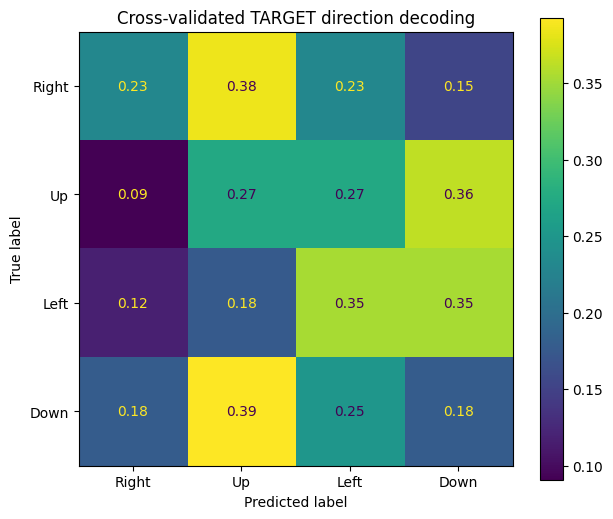

Cross-validated JOYSTICK direction decoding
Accuracy: 0.362
Balanced accuracy: 0.279
              precision    recall  f1-score   support

       Right       0.00      0.00      0.00         8
          Up       0.50      0.47      0.48        32
        Left       0.32      0.46      0.38        24
        Down       0.21      0.19      0.20        16

    accuracy                           0.36        80
   macro avg       0.26      0.28      0.27        80
weighted avg       0.34      0.36      0.35        80



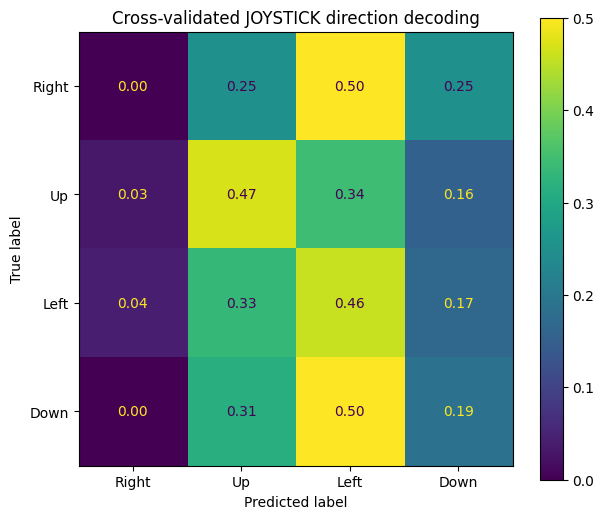

In [24]:
single_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE,
)


def plot_cv_confusion(
    y,
    class_names,
    title,
):
    predictions = cross_val_predict(
        primary_model,
        X_primary,
        y,
        cv=single_cv,
        n_jobs=-1,
    )

    balanced_acc = balanced_accuracy_score(
        y,
        predictions,
    )

    accuracy = accuracy_score(
        y,
        predictions,
    )

    print(
        f"{title}"
    )

    print(
        f"Accuracy: {accuracy:.3f}"
    )

    print(
        f"Balanced accuracy: {balanced_acc:.3f}"
    )

    print(
        classification_report(
            y,
            predictions,
            target_names=class_names,
            zero_division=0,
        )
    )

    cm = confusion_matrix(
        y,
        predictions,
        labels=np.arange(
            len(class_names)
        ),
        normalize="true",
    )

    fig, ax = plt.subplots(
        figsize=(7, 6)
    )

    display_obj = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=class_names,
    )

    display_obj.plot(
        ax=ax,
        values_format=".2f",
    )

    ax.set_title(
        title
    )

    plt.show()

    return predictions


target_predictions = plot_cv_confusion(
    target_y_primary,
    TARGET_CLASS_NAMES,
    "Cross-validated TARGET direction decoding",
)

joystick_predictions = plot_cv_confusion(
    joystick_y_primary,
    JOYSTICK_CLASS_NAMES,
    "Cross-validated JOYSTICK direction decoding",
)


# Part J: Permutation significance test

A classifier can exceed nominal 25% chance by luck in a small dataset.

The permutation test repeatedly shuffles the direction labels while keeping the neural data unchanged.

The observed CV score is then compared with that shuffled null distribution.

Default: 1000 permutations for each label.


Target direction
Observed balanced accuracy: 0.258
Permutation mean: 0.252
Permutation p-value: 0.446553


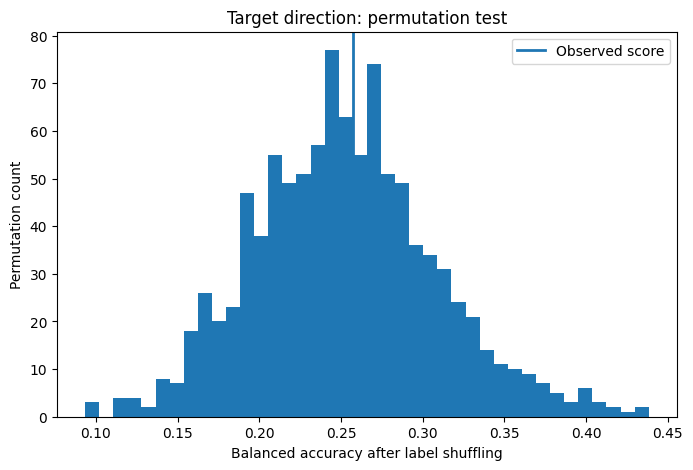

Joystick direction
Observed balanced accuracy: 0.272
Permutation mean: 0.248
Permutation p-value: 0.327672


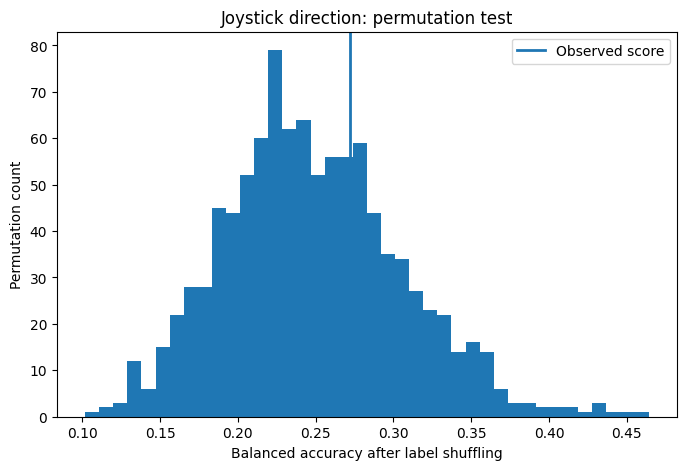

In [25]:
N_PERMUTATIONS = 1000


def run_permutation_test(
    y,
    label_name,
):
    score, permutation_scores, pvalue = (
        permutation_test_score(
            primary_model,
            X_primary,
            y,
            scoring="balanced_accuracy",
            cv=single_cv,
            n_permutations=N_PERMUTATIONS,
            n_jobs=-1,
            random_state=RANDOM_STATE,
        )
    )

    print(
        f"{label_name}"
    )

    print(
        f"Observed balanced accuracy: "
        f"{score:.3f}"
    )

    print(
        f"Permutation mean: "
        f"{np.mean(permutation_scores):.3f}"
    )

    print(
        f"Permutation p-value: "
        f"{pvalue:.6g}"
    )

    fig, ax = plt.subplots(
        figsize=(8, 5)
    )

    ax.hist(
        permutation_scores,
        bins=40,
    )

    ax.axvline(
        score,
        linewidth=2,
        label="Observed score",
    )

    ax.set_xlabel(
        "Balanced accuracy after label shuffling"
    )

    ax.set_ylabel(
        "Permutation count"
    )

    ax.set_title(
        f"{label_name}: permutation test"
    )

    ax.legend()
    plt.show()

    return {
        "observed_score": score,
        "permutation_p": pvalue,
        "null_mean": np.mean(
            permutation_scores
        ),
    }


target_permutation = run_permutation_test(
    target_y_primary,
    "Target direction",
)

joystick_permutation = run_permutation_test(
    joystick_y_primary,
    "Joystick direction",
)


# Part K: Which neural features does the classifier use?

This section fits the model on all clean trials only **after cross-validation is complete**.

This final fit is for interpretation and future prediction, not for estimating accuracy.

Feature importance is calculated from the magnitude of the logistic-regression coefficients across direction classes.


In [26]:
def fitted_feature_importance(
    X,
    y,
    info,
):
    model = make_classifier(
        X.shape[1],
        info[
            "select_k"
        ],
    )

    model.fit(
        X,
        y,
    )

    selector = model.named_steps[
        "select"
    ]

    selected_mask = selector.get_support()

    selected_names = info[
        "feature_names"
    ][
        selected_mask
    ]

    classifier = model.named_steps[
        "classifier"
    ]

    coefficients = classifier.coef_

    if coefficients.ndim == 1:
        importance = np.abs(
            coefficients
        )
    else:
        importance = np.sqrt(
            np.sum(
                coefficients ** 2,
                axis=0,
            )
        )

    table = pd.DataFrame({
        "feature": selected_names,
        "coefficient_magnitude": importance,
    })

    split = table[
        "feature"
    ].str.split(
        "|",
        expand=True,
    )

    table[
        "window"
    ] = split[0]

    table[
        "band"
    ] = split[1]

    table[
        "channel_name"
    ] = split[2]

    table = table.merge(
        intracranial_channels[
            [
                "channel_name",
                "implant_target",
            ]
        ],
        on="channel_name",
        how="left",
    )

    return (
        model,
        table.sort_values(
            "coefficient_magnitude",
            ascending=False,
        ),
    )


target_final_model, target_importance = (
    fitted_feature_importance(
        X_primary,
        target_y_primary,
        primary_info,
    )
)

joystick_final_model, joystick_importance = (
    fitted_feature_importance(
        X_primary,
        joystick_y_primary,
        primary_info,
    )
)

print("Top TARGET direction features:")
display(
    target_importance.head(25)
)

print("\nTop JOYSTICK direction features:")
display(
    joystick_importance.head(25)
)


Top TARGET direction features:


,feature,coefficient_magnitude,window,band,channel_name,implant_target
1,movement|hfb|BL7,1.440802,movement,hfb,BL7,L amygdala
17,movement|hfb|FR6,1.308991,movement,hfb,FR6,R orbitofrontal
20,movement|hfb|GR1,1.252129,movement,hfb,GR1,R opercular
11,movement|hfb|IL11,1.243074,movement,hfb,IL11,L posterior insula
12,movement|hfb|CR8,1.089888,movement,hfb,CR8,R hippocampal head
22,movement|hfb|HR2,1.064819,movement,hfb,HR2,R anterior insula ventral
10,movement|hfb|HL12,1.044225,movement,hfb,HL12,L anterior insula ventral
7,movement|hfb|GL3,1.000444,movement,hfb,GL3,L opercular
8,movement|hfb|GL4,0.971420,movement,hfb,GL4,L opercular
14,movement|hfb|ER10,0.952735,movement,hfb,ER10,R fusiform



Top JOYSTICK direction features:


,feature,coefficient_magnitude,window,band,channel_name,implant_target
9,movement|hfb|GL7,1.675609,movement,hfb,GL7,L opercular
1,movement|hfb|BL7,1.444359,movement,hfb,BL7,L amygdala
27,movement|hfb|HR1,1.325422,movement,hfb,HR1,R anterior insula ventral
28,movement|hfb|IR12,1.181333,movement,hfb,IR12,R posterior insula
16,movement|hfb|IL8,1.160150,movement,hfb,IL8,L posterior insula
22,movement|hfb|DR11,1.135529,movement,hfb,DR11,R hippocampal tail
26,movement|hfb|GR1,1.090994,movement,hfb,GR1,R opercular
25,movement|hfb|FR4,1.017928,movement,hfb,FR4,R orbitofrontal
2,movement|hfb|DL8,0.991063,movement,hfb,DL8,L hippocampal tail
3,movement|hfb|DL9,0.941889,movement,hfb,DL9,L hippocampal tail


## K1. Plot the most informative channels


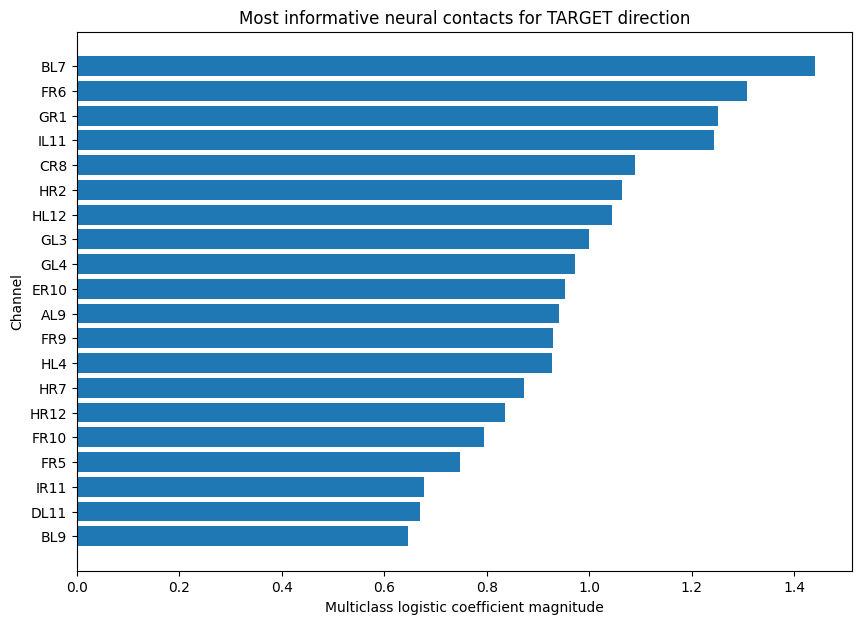

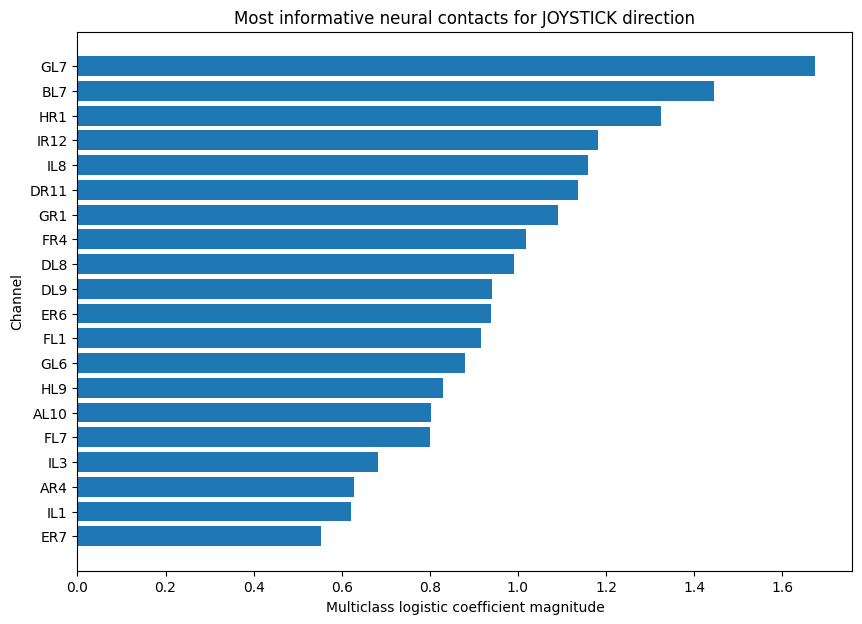

In [27]:
def plot_importance(
    table,
    title,
    n=20,
):
    plot_table = (
        table.head(
            n
        )
        .sort_values(
            "coefficient_magnitude"
        )
    )

    fig, ax = plt.subplots(
        figsize=(10, 7)
    )

    ax.barh(
        plot_table[
            "channel_name"
        ],
        plot_table[
            "coefficient_magnitude"
        ],
    )

    ax.set_xlabel(
        "Multiclass logistic coefficient magnitude"
    )

    ax.set_ylabel(
        "Channel"
    )

    ax.set_title(
        title
    )

    plt.show()


plot_importance(
    target_importance,
    "Most informative neural contacts for TARGET direction",
)

plot_importance(
    joystick_importance,
    "Most informative neural contacts for JOYSTICK direction",
)


# Part L: IL11-specific decoding plots

Because IL11 was the strongest directional channel in the earlier analysis, this section shows how its movement HFB varies across the four direction classes.

This is descriptive and should be interpreted alongside the cross-validated classifier results.


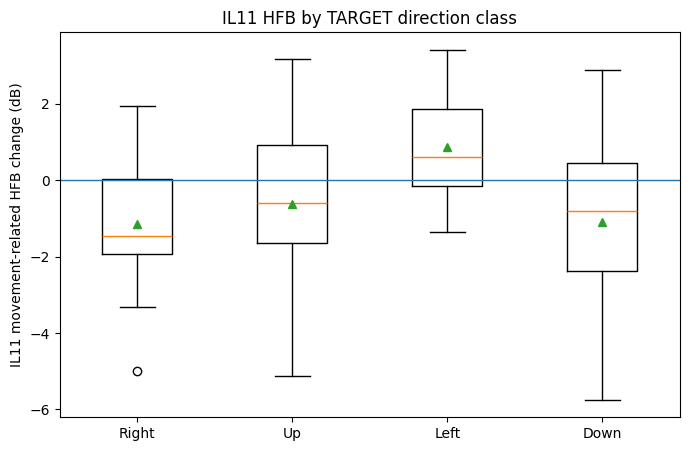

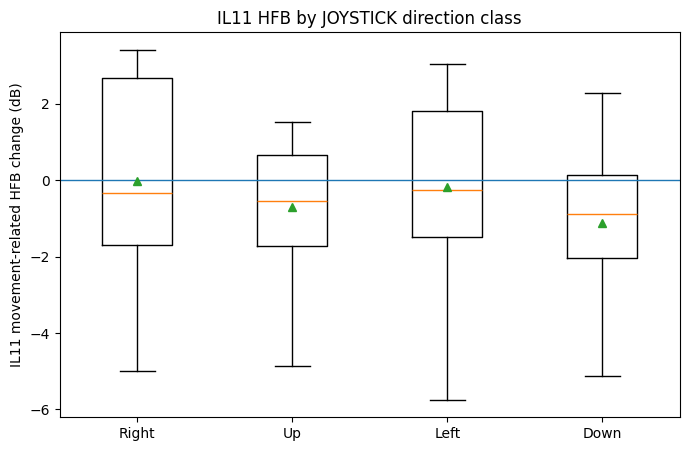

In [28]:
il11_position = int(
    np.flatnonzero(
        intracranial_names
        == "IL11"
    )[0]
)

il11_hfb = movement_hfb[
    :,
    il11_position,
]


def plot_il11_by_class(
    class_column,
    class_names,
    title,
):
    values = []

    for class_name in class_names:
        mask = (
            neural_trials[
                class_column
            ]
            == class_name
        ).to_numpy()

        mask &= analysis_mask

        values.append(
            il11_hfb[
                mask
            ]
        )

    fig, ax = plt.subplots(
        figsize=(8, 5)
    )

    ax.boxplot(
        values,
        tick_labels=class_names,
        showmeans=True,
    )

    ax.axhline(
        0,
        linewidth=1,
    )

    ax.set_ylabel(
        "IL11 movement-related HFB change (dB)"
    )

    ax.set_title(
        title
    )

    plt.show()


plot_il11_by_class(
    "target_class",
    TARGET_CLASS_NAMES,
    "IL11 HFB by TARGET direction class",
)

plot_il11_by_class(
    "joystick_class",
    JOYSTICK_CLASS_NAMES,
    "IL11 HFB by JOYSTICK direction class",
)


## L1. Raw IL11 traces by direction class

This is an artifact sanity check.

If one direction class has a dramatic raw-voltage step, spike, clipping pattern, or noise burst that the others lack, decoding may be artifact-driven.


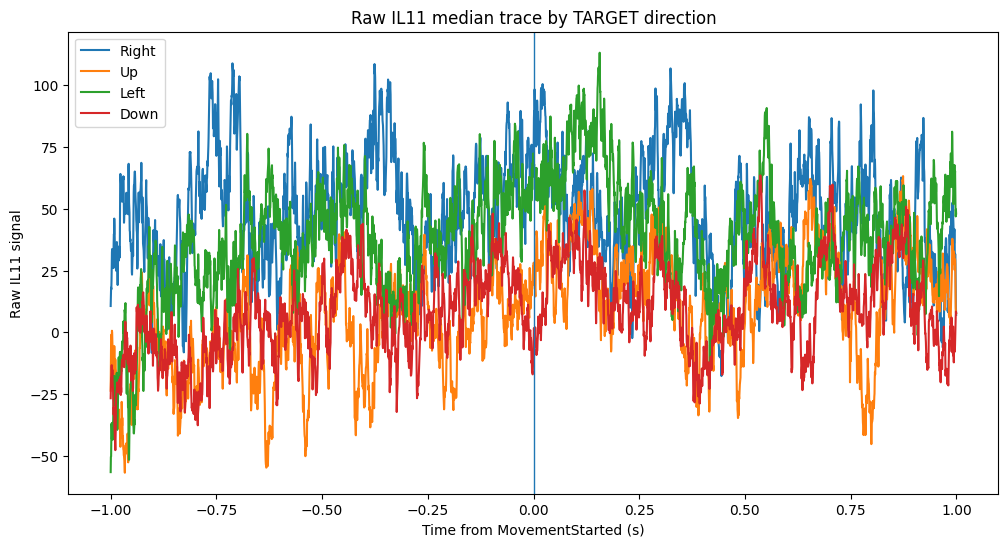

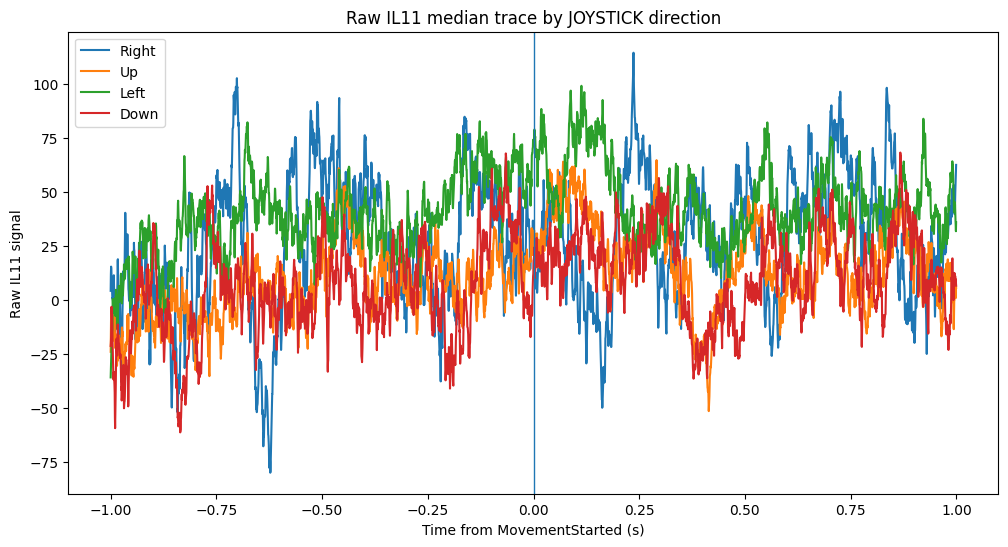

In [29]:
RAW_WINDOW = (
    -1.0,
    1.0,
)

raw_offsets = np.arange(
    int(
        round(
            RAW_WINDOW[0]
            * fs
        )
    ),
    int(
        round(
            RAW_WINDOW[1]
            * fs
        )
    ),
)

raw_time = (
    raw_offsets
    / fs
)

il11_signal_index = int(
    intracranial_channels.loc[
        intracranial_channels[
            "channel_name"
        ] == "IL11",
        "signal_index",
    ].iloc[0]
)


def median_raw_trace_by_class(
    class_column,
    class_names,
    title,
):
    fig, ax = plt.subplots(
        figsize=(12, 6)
    )

    for class_name in class_names:
        traces = []

        class_mask = (
            neural_trials[
                class_column
            ]
            == class_name
        ).to_numpy()

        class_mask &= analysis_mask

        for trial_i in np.flatnonzero(
            class_mask
        ):
            onset = int(
                neural_trials.iloc[
                    trial_i
                ][
                    "movement_onset_sample"
                ]
            )

            indices = (
                onset
                + raw_offsets
            )

            if (
                indices[0] < 0
                or indices[-1] >= n_samples
            ):
                continue

            traces.append(
                signal[
                    indices,
                    il11_signal_index,
                ].astype(
                    np.float64
                )
            )

        if len(traces) == 0:
            continue

        traces = np.vstack(
            traces
        )

        ax.plot(
            raw_time,
            np.nanmedian(
                traces,
                axis=0,
            ),
            label=class_name,
        )

    ax.axvline(
        0,
        linewidth=1,
    )

    ax.set_xlabel(
        "Time from MovementStarted (s)"
    )

    ax.set_ylabel(
        "Raw IL11 signal"
    )

    ax.set_title(
        title
    )

    ax.legend()
    plt.show()


median_raw_trace_by_class(
    "target_class",
    TARGET_CLASS_NAMES,
    "Raw IL11 median trace by TARGET direction",
)

median_raw_trace_by_class(
    "joystick_class",
    JOYSTICK_CLASS_NAMES,
    "Raw IL11 median trace by JOYSTICK direction",
)


# Part M: Check whether direction classes differ in artifact metrics

If direction classes differ systematically in raw RMS, peak-to-peak amplitude, or 120 Hz contamination, a neural classifier could accidentally decode those artifacts instead of movement direction.


In [30]:
artifact_analysis_table = (
    neural_trials[
        [
            "target_class",
            "joystick_class",
        ]
    ]
    .reset_index(
        drop=True
    )
    .join(
        artifact_table[
            [
                "movement_ptp_median",
                "movement_rms_median",
                "movement_120_abs_median",
                "movement_ptp_p99",
            ]
        ]
    )
)

for label_column in [
    "target_class",
    "joystick_class",
]:
    print(
        f"\nArtifact metrics by {label_column}:"
    )

    display(
        artifact_analysis_table.groupby(
            label_column
        )[
            [
                "movement_ptp_median",
                "movement_rms_median",
                "movement_120_abs_median",
                "movement_ptp_p99",
            ]
        ].mean()
    )

    for metric in [
        "movement_ptp_median",
        "movement_rms_median",
        "movement_120_abs_median",
        "movement_ptp_p99",
    ]:
        groups_metric = [
            artifact_analysis_table.loc[
                artifact_analysis_table[
                    label_column
                ] == class_name,
                metric,
            ].dropna().to_numpy()
            for class_name in (
                TARGET_CLASS_NAMES
                if label_column
                == "target_class"
                else JOYSTICK_CLASS_NAMES
            )
        ]

        if all(
            len(group) >= 2
            for group in groups_metric
        ):
            test = f_oneway(
                *groups_metric
            )

            print(
                f"{metric}: "
                f"ANOVA p={test.pvalue:.4g}"
            )



Artifact metrics by target_class:


,movement_ptp_median,movement_rms_median,movement_120_abs_median,movement_ptp_p99
target_class,,,,
Down,217.818778,67.777260,5.103086,684.497524
Left,213.798254,66.923320,5.445038,697.332778
Right,209.589093,63.701207,5.596166,635.174504
Up,210.824308,74.328185,5.115603,638.473544


movement_ptp_median: ANOVA p=0.8062
movement_rms_median: ANOVA p=0.2621
movement_120_abs_median: ANOVA p=0.9391
movement_ptp_p99: ANOVA p=0.78

Artifact metrics by joystick_class:


,movement_ptp_median,movement_rms_median,movement_120_abs_median,movement_ptp_p99
joystick_class,,,,
Down,212.231445,69.374952,5.840974,646.141602
Left,205.263265,64.309446,5.416405,589.914591
Right,207.165527,70.616291,4.109949,642.497681
Up,222.404480,71.263726,5.138019,740.252411


movement_ptp_median: ANOVA p=0.1593
movement_rms_median: ANOVA p=0.4656
movement_120_abs_median: ANOVA p=0.5348
movement_ptp_p99: ANOVA p=0.08382


# Part N: Compare target decoding with joystick decoding

This summary helps answer a mechanistic question:

### If target direction decodes better
The neural representation may be more related to the visual goal, cursor trajectory, or intended target.

### If physical joystick direction decodes better
The signal may be more closely related to the actual hand/motor command or movement-related sensory feedback.

### If both decode well
The region may carry a mixture of goal and movement information, or the two variables may remain correlated enough to support both.


In [31]:
summary_rows = []

for label_name, result_table, permutation_result in [
    (
        "Target direction",
        target_random_results,
        target_permutation,
    ),
    (
        "Joystick direction",
        joystick_random_results,
        joystick_permutation,
    ),
]:
    primary_row = result_table.loc[
        result_table[
            "dataset"
        ] == PRIMARY_DATASET
    ].iloc[0]

    blocked_row = blocked_results.loc[
        (
            blocked_results[
                "label"
            ] == label_name
        )
        & (
            blocked_results[
                "dataset"
            ] == PRIMARY_DATASET
        )
    ].iloc[0]

    summary_rows.append({
        "label": label_name,
        "repeated_CV_balanced_accuracy": primary_row[
            "balanced_accuracy_mean"
        ],
        "blocked_CV_balanced_accuracy": blocked_row[
            "blocked_balanced_accuracy_mean"
        ],
        "permutation_p": permutation_result[
            "permutation_p"
        ],
        "chance_for_balanced_classes": (
            1.0
            / N_DIRECTION_CLASSES
        ),
    })

decoding_summary = pd.DataFrame(
    summary_rows
)

display(
    decoding_summary
)


,label,repeated_CV_balanced_accuracy,blocked_CV_balanced_accuracy,permutation_p,chance_for_balanced_classes
0,Target direction,0.250167,0.261741,0.446553,0.25
1,Joystick direction,0.247048,0.179549,0.327672,0.25


# Part O: Train final models and save them

Only do this **after** examining the cross-validation and permutation results.

These models are fitted on all clean trials and are intended for future prediction, not for estimating performance.

The saved object includes:

- trained classifier
- class names
- feature names
- selected neural-feature definition
- artifact-exclusion setting
- number of direction classes
- target-circle geometry


In [32]:
import joblib

SAVE_FINAL_MODELS = False

if SAVE_FINAL_MODELS:
    target_final_model.fit(
        X_primary,
        target_y_primary,
    )

    joystick_final_model.fit(
        X_primary,
        joystick_y_primary,
    )

    metadata_common = {
        "primary_dataset": PRIMARY_DATASET,
        "feature_names": primary_info[
            "feature_names"
        ],
        "n_direction_classes": N_DIRECTION_CLASSES,
        "artifact_exclusion": EXCLUDE_ARTIFACT_TRIALS,
        "sampling_rate_hz": fs,
        "target_center_x": target_center_x,
        "target_center_y": target_center_y,
        "target_radius": target_radius,
        "bands": BANDS,
        "windows": WINDOWS,
        "line_frequencies_excluded": LINE_FREQS,
    }

    joblib.dump(
        {
            "model": target_final_model,
            "class_names": TARGET_CLASS_NAMES,
            "label": "target_direction",
            **metadata_common,
        },
        "target_direction_neural_classifier.joblib",
    )

    joblib.dump(
        {
            "model": joystick_final_model,
            "class_names": JOYSTICK_CLASS_NAMES,
            "label": "joystick_direction",
            **metadata_common,
        },
        "joystick_direction_neural_classifier.joblib",
    )

    print(
        "Saved target_direction_neural_classifier.joblib"
    )

    print(
        "Saved joystick_direction_neural_classifier.joblib"
    )
else:
    print(
        "SAVE_FINAL_MODELS is False. "
        "Review the validation results before saving a final model."
    )


SAVE_FINAL_MODELS is False. Review the validation results before saving a final model.


# Interpretation guide

## Strong evidence for real neural decoding would look like:

- repeated-CV balanced accuracy clearly above nominal chance
- permutation p-value below 0.05
- leave-one-block-out accuracy remaining above chance
- performance surviving global-HFB correction
- performance surviving artifact-trial exclusion
- informative features clustering in plausible local neural contacts
- raw traces not showing direction-specific spikes, clipping, or large DC steps
- artifact metrics not differing systematically by direction class

## Pre-movement decoding is particularly important

If direction can be decoded from the **pre-movement** window, then the signal contains information before the physical joystick movement begins.

That would make a pure movement artifact explanation substantially less likely and would be relevant for BCI applications.

## Movement-period decoding is easier to interpret cautiously

High movement-period accuracy may reflect:

- motor command
- proprioceptive feedback
- somatosensory feedback
- visual feedback
- movement-related artifact
- some combination of these

The artifact and blocked-CV analyses help separate these possibilities.

## IL11

If IL11 or its neighboring posterior-insula contacts repeatedly appear among the most informative neural features, and the result survives blocked CV and global correction, that would provide a strong follow-up to the earlier IL11 direction-tuning result.

## Dataset size

There are only about 80 completed trials. Treat this as an exploratory decoder.

A robust claim would require replication in additional runs and participants, ideally with a design in which direction, task condition, and block order are independently randomized.
